# HW-III: Longitudinal MI Training and Plasticity
## ECE-374N/385J Neural Engineering — Spring 2024

Analysis of neuro-plastic effects of longitudinal Motor Imagery (MI) BCI training for two healthy subjects.
- 7 sessions each: 1 offline + 6 online
- 3 runs per session, 20 trials per run
- 32-channel EEG, fs = 512 Hz

## Setup & Data Loading

In [37]:
import numpy as np
import scipy.io as sio
from scipy import signal, stats
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Circle
import pymannkendall as mk
import warnings
warnings.filterwarnings('ignore')

# MNE for topoplots
import mne
from mne.viz import plot_topomap
mne.set_log_level('WARNING')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

DATA_DIR = 'HW_3_sp23_longitudinalTraining_Plasticity_ECE374N-385J_Neural_Eng/'
print('Setup complete.')

Setup complete.


In [38]:
# ── Load subject data ───────────────────────────────────────────────────────

def load_subject(mat_path):
    """Load a subject .mat file and return the struct."""
    data = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    key = [k for k in data if not k.startswith('_')][0]
    return data[key]

subj1 = load_subject(DATA_DIR + 'subj1.mat')
subj2 = load_subject(DATA_DIR + 'subj2.mat')
subjects = [subj1, subj2]
subj_names = ['Subject-1', 'Subject-2']
N_SESSIONS = 6   # online sessions
N_RUNS = 3
N_TRIALS = 20    # per run
FS = subj1.offline.run[0].header.fs  # 512 Hz

# ── Load channel locations ──────────────────────────────────────────────────
loc_data = sio.loadmat('ch32Locations.mat', squeeze_me=True, struct_as_record=False)
ch_locs = loc_data['ch32Locations']
CH_LABELS = np.array([ch_locs[i].labels for i in range(32)])
# 3-D Cartesian (EEGLAB convention: X=nose, Y=left, Z=up)
X_eeg = np.array([ch_locs[i].X for i in range(32)])
Y_eeg = np.array([ch_locs[i].Y for i in range(32)])
# Convert to 2-D topomap coords: mne expects (right, front)
pos2d = np.column_stack([-Y_eeg, X_eeg])
pos2d = pos2d / np.max(np.linalg.norm(pos2d, axis=1))  # normalise to unit circle

print(f'fs = {FS} Hz')
print(f'Channels ({len(CH_LABELS)}):', CH_LABELS)
print('Subjects loaded.')

# ── Event sequence: Subject 1, Session 1, Run 1 ─────────────────────────────
typs_s1_s1_r1 = subj1.online[0].run[0].header.triggers.TYP
pos_s1_s1_r1  = subj1.online[0].run[0].header.triggers.POS
print('\nSubject 1 | Online Session 1 | Run 1 — Event sequence:')
print(f'  {"#":<5} {"POS (sample)":>14}  {"TYP":>8}')
print(f'  {"-"*5} {"-"*14}  {"-"*8}')
for i, (p, t) in enumerate(zip(pos_s1_s1_r1, typs_s1_s1_r1)):
    print(f'  {i:<5} {p:>14}  {t:>8}')

fs = 512 Hz
Channels (32): ['Fp1' 'Fpz' 'Fp2' 'F7' 'F3' 'Fz' 'F4' 'F8' 'FC5' 'FC1' 'FC2' 'FC6' 'M1'
 'T7' 'C3' 'Cz' 'C4' 'T8' 'M2' 'CP5' 'CP1' 'CP2' 'CP6' 'P7' 'P3' 'Pz' 'P4'
 'P8' 'POz' 'O1' 'Oz' 'O2']
Subjects loaded.

Subject 1 | Online Session 1 | Run 1 — Event sequence:
  #       POS (sample)       TYP
  ----- --------------  --------
  0               6922     32766
  1               7183      1000
  2               8653       768
  3               9681       769
  4              10706      7691
  5              10938      7692
  6              11710      1000
  7              12936       768
  8              13971       770
  9              14998      7701
  10             15324      7702
  11             16097      1000
  12             17186       768
  13             18218       769
  14             19243      7691
  15             21083      7692
  16             21861      1000
  17             23325       768
  18             24359       770
  19             25384      770

---
# Section 2.1 — BCI Command Delivery

Subject-1
  ------------------------------------------------
                  Run 1    Run 2    Run 3     Mean
  ------------------------------------------------
  Session 1       55.0%    45.0%    55.0%    51.7%   acc
                  15.0%    30.0%    25.0%    23.3%   timeout
  Session 2       60.0%    50.0%    45.0%    51.7%   acc
                  35.0%    25.0%    50.0%    36.7%   timeout
  Session 3       45.0%    65.0%    60.0%    56.7%   acc
                  35.0%    35.0%    40.0%    36.7%   timeout
  Session 4       50.0%    60.0%    30.0%    46.7%   acc
                  45.0%    40.0%    65.0%    50.0%   timeout
  Session 5       65.0%    80.0%    70.0%    71.7%   acc
                  25.0%    20.0%    15.0%    20.0%   timeout
  Session 6       80.0%    50.0%    35.0%    55.0%   acc
                  15.0%    40.0%    45.0%    33.3%   timeout
  ------------------------------------------------
  Overall acc     55.6%
  Overall t/o     33.3%

Subject-2
  -----------------

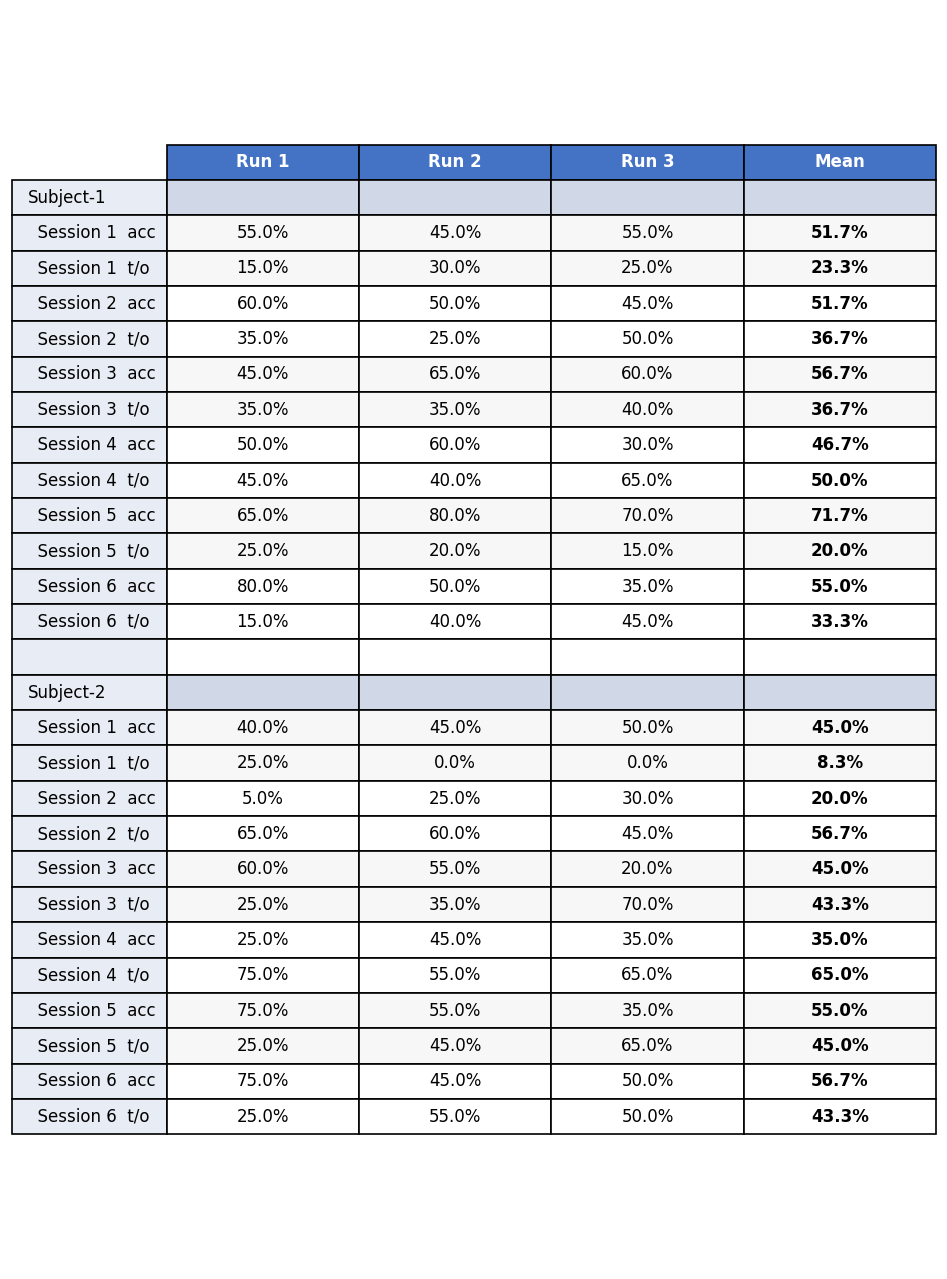

Saved table_accuracy_timeout.png


In [39]:
TIMEOUT_THRESH_SAMP = int(6.9 * FS)  # 6.9 s in samples

accuracy     = []   # 2 x 6 x 3
timeout_rate = []   # 2 x 6 x 3

for subj in [subj1, subj2]:
    subj_session_run_accuracy     = []
    subj_session_run_timeout_rate = []
    for session in subj.online:
        session_run_accuracy     = []
        session_run_timeout_rate = []
        for run in session.run:
            trial_start_samp = 0
            run_hits     = 0
            run_timeouts = 0
            run_total    = 0
            for typ, pos in zip(run.header.triggers.TYP, run.header.triggers.POS):
                if (typ == 7691) or (typ == 7701):
                    trial_start_samp = pos
                elif (typ == 7692) or (typ == 7702):
                    run_total += 1
                    if (pos - trial_start_samp) >= TIMEOUT_THRESH_SAMP:
                        run_timeouts += 1
                elif (typ == 7693) or (typ == 7703):
                    run_hits  += 1
                    run_total += 1
            session_run_accuracy.append(run_hits     / run_total)
            session_run_timeout_rate.append(run_timeouts / run_total)
        subj_session_run_accuracy.append(session_run_accuracy)
        subj_session_run_timeout_rate.append(session_run_timeout_rate)
    accuracy.append(subj_session_run_accuracy)
    timeout_rate.append(subj_session_run_timeout_rate)

accuracy     = np.array(accuracy)      # (2, 6, 3)
timeout_rate = np.array(timeout_rate)  # (2, 6, 3)

# ── Pretty-print ─────────────────────────────────────────────────────────────
header = f"  {"":<12}  {"Run 1":>7}  {"Run 2":>7}  {"Run 3":>7}  {"Mean":>7}"
sep = "  " + "-" * (len(header) - 2)
for si, name in enumerate(["Subject-1", "Subject-2"]):
    print(f"{name}")
    print(sep)
    print(header)
    print(sep)
    for sess_idx in range(6):
        accs = accuracy[si, sess_idx]
        tos  = timeout_rate[si, sess_idx]
        runs_acc = "".join([f"  {a*100:6.1f}%" for a in accs])
        runs_to  = "".join([f"  {t*100:6.1f}%" for t in tos])
        print(f"  Session {sess_idx+1:<4}{runs_acc}  {accs.mean()*100:6.1f}%   acc")
        print(f"  {"":<12}{runs_to}  {tos.mean()*100:6.1f}%   timeout")
    print(sep)
    print(f"  {"Overall acc":<12}{""*24}  {accuracy[si].mean()*100:6.1f}%")
    print(f"  {"Overall t/o":<12}{""*24}  {timeout_rate[si].mean()*100:6.1f}%")
    print()

# ── Save table as PNG ─────────────────────────────────────────────────────────
col_labels = ['Run 1', 'Run 2', 'Run 3', 'Mean']
row_labels, cell_vals, row_colors = [], [], []
for si, name in enumerate(['Subject-1', 'Subject-2']):
    if si > 0:
        row_labels.append(''); cell_vals.append([''] * 4); row_colors.append(['#ffffff'] * 4)
    row_labels.append(name); cell_vals.append([''] * 4); row_colors.append(['#d0d8e8'] * 4)
    for sess_idx in range(6):
        accs = accuracy[si, sess_idx]
        tos  = timeout_rate[si, sess_idx]
        row_labels.append(f'  Session {sess_idx+1}  acc')
        cell_vals.append([f'{a*100:.1f}%' for a in accs] + [f'{accs.mean()*100:.1f}%'])
        bg = '#f7f7f7' if sess_idx % 2 == 0 else '#ffffff'
        row_colors.append([bg] * 4)
        row_labels.append(f'  Session {sess_idx+1}  t/o')
        cell_vals.append([f'{t*100:.1f}%' for t in tos] + [f'{tos.mean()*100:.1f}%'])
        row_colors.append([bg] * 4)

fig, ax = plt.subplots(figsize=(8, len(row_labels) * 0.38 + 0.5))
ax.axis('off')
tbl = ax.table(
    cellText=cell_vals,
    rowLabels=row_labels,
    colLabels=col_labels,
    cellLoc='center',
    rowLoc='left',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.4)

# Apply row background colours
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#4472c4')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == -1:
        cell.set_facecolor('#e8ecf4')
    elif row - 1 < len(row_colors):
        cell.set_facecolor(row_colors[row - 1][col])
    if col == 3:
        cell.set_text_props(fontweight='bold')

plt.tight_layout()
plt.savefig('table_accuracy_timeout.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved table_accuracy_timeout.png')


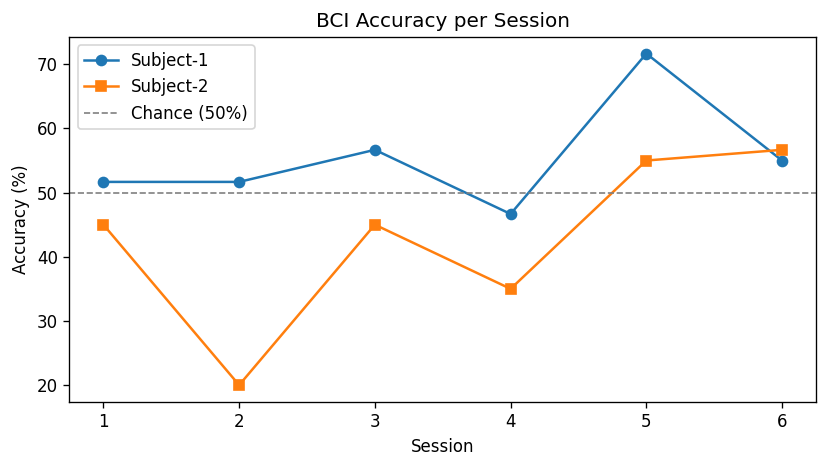

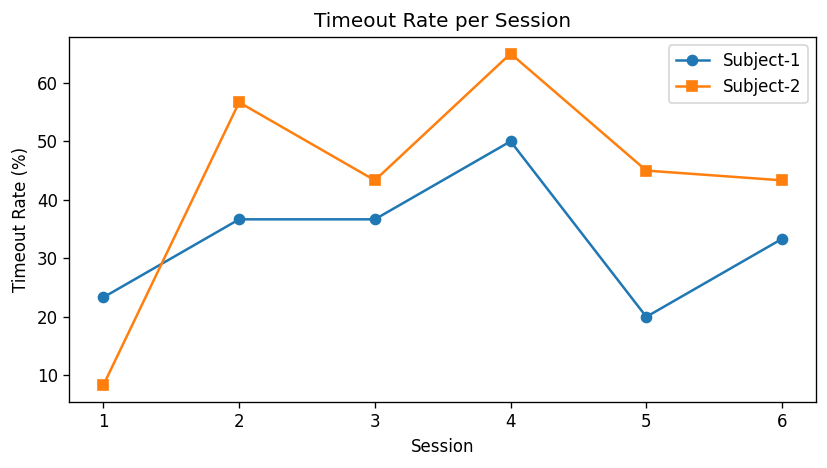

In [56]:
sessions = range(1, 7)
acc_s1 = [sum(r) / len(r) for r in accuracy[0]]
acc_s2 = [sum(r) / len(r) for r in accuracy[1]]

plt.figure(figsize=(7, 4))
plt.plot(sessions, [a * 100 for a in acc_s1], "o-", label="Subject-1")
plt.plot(sessions, [a * 100 for a in acc_s2], "s-", label="Subject-2")
plt.axhline(50, color="gray", linestyle="--", linewidth=1, label="Chance (50%)")
plt.xlabel("Session")
plt.ylabel("Accuracy (%)")
plt.title("BCI Accuracy per Session")
plt.xticks(sessions)
plt.legend()
plt.tight_layout()
plt.show()

to_s1 = [sum(r) / len(r) for r in timeout_rate[0]]
to_s2 = [sum(r) / len(r) for r in timeout_rate[1]]

plt.figure(figsize=(7, 4))
plt.plot(sessions, [t * 100 for t in to_s1], "o-", label="Subject-1")
plt.plot(sessions, [t * 100 for t in to_s2], "s-", label="Subject-2")
plt.xlabel("Session")
plt.ylabel("Timeout Rate (%)")
plt.title("Timeout Rate per Session")
plt.xticks(sessions)
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
from scipy.stats import pearsonr, mannwhitneyu

sessions = np.arange(1, 7)

def sig_stars(p):
    return '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))

# ── Pearson: session number vs accuracy ──────────────────────────────────────
print('=' * 68)
print('PEARSON CORRELATION  —  session number vs accuracy')
print('=' * 68)

acc_group_mean = accuracy.mean(axis=(0, 2))          # (6,) mean over subjects & runs
r, p = pearsonr(sessions, acc_group_mean)
print(f'  {"Group":<14}  r = {r:+.3f}   p = {p:.4f}  {sig_stars(p)}'
      f'   (mean {acc_group_mean.mean()*100:.1f}%)')

for si, name in enumerate(['Subject-1', 'Subject-2']):
    sess_mean = accuracy[si].mean(axis=1)            # (6,)
    r, p = pearsonr(sessions, sess_mean)
    print(f'  {name:<14}  r = {r:+.3f}   p = {p:.4f}  {sig_stars(p)}'
          f'   (mean {sess_mean.mean()*100:.1f}%)')

# ── Wilcoxon rank-sum: sessions 1-3 vs 4-6, accuracy ────────────────────────
print()
print('=' * 68)
print('WILCOXON RANK-SUM  —  sessions 1-3 vs 4-6  (accuracy)')
print('=' * 68)

early_g = accuracy[:, :3, :].flatten()
late_g  = accuracy[:, 3:, :].flatten()
stat, p = mannwhitneyu(early_g, late_g, alternative='two-sided')
print(f'  {"Group":<14}  U = {stat:.0f}   p = {p:.4f}  {sig_stars(p)}'
      f'   early {early_g.mean()*100:.1f}%  ->  late {late_g.mean()*100:.1f}%')

for si, name in enumerate(['Subject-1', 'Subject-2']):
    early = accuracy[si, :3, :].flatten()
    late  = accuracy[si, 3:, :].flatten()
    stat, p = mannwhitneyu(early, late, alternative='two-sided')
    print(f'  {name:<14}  U = {stat:.0f}   p = {p:.4f}  {sig_stars(p)}'
          f'   early {early.mean()*100:.1f}%  ->  late {late.mean()*100:.1f}%')

# ── Pearson: session number vs timeout rate ──────────────────────────────────
print()
print('=' * 68)
print('PEARSON CORRELATION  —  session number vs timeout rate')
print('=' * 68)

to_group_mean = timeout_rate.mean(axis=(0, 2))       # (6,)
r, p = pearsonr(sessions, to_group_mean)
print(f'  {"Group":<14}  r = {r:+.3f}   p = {p:.4f}  {sig_stars(p)}'
      f'   (mean {to_group_mean.mean()*100:.1f}%)')

for si, name in enumerate(['Subject-1', 'Subject-2']):
    sess_mean = timeout_rate[si].mean(axis=1)
    r, p = pearsonr(sessions, sess_mean)
    print(f'  {name:<14}  r = {r:+.3f}   p = {p:.4f}  {sig_stars(p)}'
          f'   (mean {sess_mean.mean()*100:.1f}%)')

# ── Wilcoxon rank-sum: sessions 1-3 vs 4-6, timeout rate ────────────────────
print()
print('=' * 68)
print('WILCOXON RANK-SUM  —  sessions 1-3 vs 4-6  (timeout rate)')
print('=' * 68)

early_g = timeout_rate[:, :3, :].flatten()
late_g  = timeout_rate[:, 3:, :].flatten()
stat, p = mannwhitneyu(early_g, late_g, alternative='two-sided')
print(f'  {"Group":<14}  U = {stat:.0f}   p = {p:.4f}  {sig_stars(p)}'
      f'   early {early_g.mean()*100:.1f}%  ->  late {late_g.mean()*100:.1f}%')

for si, name in enumerate(['Subject-1', 'Subject-2']):
    early = timeout_rate[si, :3, :].flatten()
    late  = timeout_rate[si, 3:, :].flatten()
    stat, p = mannwhitneyu(early, late, alternative='two-sided')
    print(f'  {name:<14}  U = {stat:.0f}   p = {p:.4f}  {sig_stars(p)}'
          f'   early {early.mean()*100:.1f}%  ->  late {late.mean()*100:.1f}%')

# ── Mann-Kendall: trend over sessions, accuracy ───────────────────────────────
import pymannkendall as mk

print()
print('=' * 68)
print('MANN-KENDALL TREND TEST  —  accuracy')
print('=' * 68)

acc_group_mean = accuracy.mean(axis=(0, 2))
res = mk.original_test(acc_group_mean)
print(f'  {"Group":<14}  tau = {res.Tau:+.3f}   p = {res.p:.4f}  {sig_stars(res.p)}   trend: {res.trend}')

for si, name in enumerate(['Subject-1', 'Subject-2']):
    sess_mean = accuracy[si].mean(axis=1)
    res = mk.original_test(sess_mean)
    print(f'  {name:<14}  tau = {res.Tau:+.3f}   p = {res.p:.4f}  {sig_stars(res.p)}   trend: {res.trend}')

# ── Mann-Kendall: trend over sessions, timeout rate ───────────────────────────
print()
print('=' * 68)
print('MANN-KENDALL TREND TEST  —  timeout rate')
print('=' * 68)

to_group_mean = timeout_rate.mean(axis=(0, 2))
res = mk.original_test(to_group_mean)
print(f'  {"Group":<14}  tau = {res.Tau:+.3f}   p = {res.p:.4f}  {sig_stars(res.p)}   trend: {res.trend}')

for si, name in enumerate(['Subject-1', 'Subject-2']):
    sess_mean = timeout_rate[si].mean(axis=1)
    res = mk.original_test(sess_mean)
    print(f'  {name:<14}  tau = {res.Tau:+.3f}   p = {res.p:.4f}  {sig_stars(res.p)}   trend: {res.trend}')


PEARSON CORRELATION  —  session number vs accuracy
  Group           r = +0.590   p = 0.2173  ns   (mean 49.2%)
  Subject-1       r = +0.414   p = 0.4144  ns   (mean 55.6%)
  Subject-2       r = +0.600   p = 0.2075  ns   (mean 42.8%)

WILCOXON RANK-SUM  —  sessions 1-3 vs 4-6  (accuracy)
  Group           U = 126   p = 0.2655  ns   early 45.0%  ->  late 53.3%
  Subject-1       U = 32   p = 0.4494  ns   early 53.3%  ->  late 57.8%
  Subject-2       U = 28   p = 0.2675  ns   early 36.7%  ->  late 48.9%

PEARSON CORRELATION  —  session number vs timeout rate
  Group           r = +0.334   p = 0.5175  ns   (mean 38.5%)
  Subject-1       r = +0.066   p = 0.9007  ns   (mean 33.3%)
  Subject-2       r = +0.446   p = 0.3750  ns   (mean 43.6%)

WILCOXON RANK-SUM  —  sessions 1-3 vs 4-6  (timeout rate)
  Group           U = 124   p = 0.2263  ns   early 34.2%  ->  late 42.8%
  Subject-1       U = 37   p = 0.7893  ns   early 32.2%  ->  late 34.4%
  Subject-2       U = 28   p = 0.2655  ns   early 3

In [42]:
from scipy.stats import wilcoxon

# ── Session-vs-session-1 comparison ──────────────────────────────────────────
# Paired by run index within subject; group level pools both subjects (6 pairs).
# Wilcoxon signed-rank used throughout (matched pairs, non-parametric).

for arr, label in [
        (accuracy,     'accuracy'),
        (timeout_rate, 'timeout rate'),
]:
    print('=' * 72)
    print(f'WILCOXON RANK-SUM  —  each session vs session 1  ({label})')
    print(f'  {"":20}  {"stat":>6}  {"p":>8}  sig   sess1 mean  sess_s mean')
    print('  ' + '-' * 68)
    for sess_idx in range(1, 6):                  # sessions 2-6 (0-indexed 1-5)
        # Group level: pool both subjects -> 6 pairs
        ref_g = arr[:, 0, :].flatten()            # session 1, all runs, both subj
        cmp_g = arr[:, sess_idx, :].flatten()
        try:
            stat, p = wilcoxon(cmp_g, ref_g)
        except ValueError:
            stat, p = np.nan, 1.0
        print(f'  {"Group":<20}  {stat:>6.1f}  {p:>8.4f}  {sig_stars(p)}'
              f'   {ref_g.mean()*100:6.1f}%  ->  {cmp_g.mean()*100:6.1f}%'
              f'   [sess 1 vs {sess_idx+1}]')

        for si, name in enumerate(['Subject-1', 'Subject-2']):
            ref_s = arr[si, 0, :]                 # 3 runs from session 1
            cmp_s = arr[si, sess_idx, :]          # 3 runs from session s
            try:
                stat, p = wilcoxon(cmp_s, ref_s)
            except ValueError:
                stat, p = np.nan, 1.0
            print(f'  {name:<20}  {stat:>6.1f}  {p:>8.4f}  {sig_stars(p)}'
                  f'   {ref_s.mean()*100:6.1f}%  ->  {cmp_s.mean()*100:6.1f}%')
        print()
    print()


WILCOXON RANK-SUM  —  each session vs session 1  (accuracy)
                          stat         p  sig   sess1 mean  sess_s mean
  --------------------------------------------------------------------
  Group                    3.0    0.1562  ns     48.3%  ->    35.8%   [sess 1 vs 2]
  Subject-1                3.0    1.0000  ns     51.7%  ->    51.7%
  Subject-2                0.0    0.2500  ns     45.0%  ->    20.0%

  Group                    8.5    0.7500  ns     48.3%  ->    50.8%   [sess 1 vs 3]
  Subject-1                2.0    0.7500  ns     51.7%  ->    56.7%
  Subject-2                3.0    1.0000  ns     45.0%  ->    45.0%

  Group                    2.0    0.1875  ns     48.3%  ->    40.8%   [sess 1 vs 4]
  Subject-1                2.0    0.7500  ns     51.7%  ->    46.7%
  Subject-2                0.0    0.5000  ns     45.0%  ->    35.0%

  Group                    4.0    0.2188  ns     48.3%  ->    63.3%   [sess 1 vs 5]
  Subject-1                0.0    0.2500  ns     5

---
# Section 2.2 — PSD Feature Extraction

In [45]:
# ── PSD Feature Extraction via Welch's Method ─────────────────────────────
# Task period: from MI cue onset (TYP 769/770) to trial-end trigger
# (TYP 7692/7693 for left, 7702/7703 for right).
#
# Frequency bins: 4, 6, 8, ..., 30 Hz  →  14 bins
# Channels: 32
# Features per trial: 32 × 14 = 448

FREQ_BINS  = np.arange(4, 32, 2)        # [4, 6, 8, ..., 30] Hz — 14 bins
N_FREQ     = len(FREQ_BINS)             # 14
N_CH       = 32
N_FEATURES = N_CH * N_FREQ             # 448

# Welch parameters: nperseg = FS/2 → frequency resolution = FS/nperseg = 2 Hz
NPERSEG  = FS // 2                      # 256 samples
NOVERLAP = NPERSEG // 2                 # 128 samples (50 % overlap)

# ── Trigger constants ────────────────────────────────────────────────────────
CUE_TYPES = {769, 770}                   # MI cue onset (class label)
TRIAL_END = {7692, 7693, 7702, 7703}    # hit / timeout / miss

# psd_all[subj_idx][sess_idx][run_idx] → ndarray (n_trials, 448)
# lbl_all[subj_idx][sess_idx][run_idx] → ndarray (n_trials,)  {769, 770}
psd_all = []
lbl_all = []

for subj in subjects:
    psd_subj, lbl_subj = [], []

    for sess in subj.online:                     # 6 online sessions
        psd_sess, lbl_sess = [], []

        for run in sess.run:                     # 3 runs per session
            typs = run.header.triggers.TYP
            pos  = run.header.triggers.POS
            eeg  = run.eeg                       # (n_samples, 32)

            run_feats, run_lbls = [], []
            cue_samp  = None
            cue_class = None

            for typ, p in zip(typs, pos):
                if typ in CUE_TYPES:
                    cue_samp  = p
                    cue_class = typ
                elif typ in TRIAL_END and cue_samp is not None:
                    seg = eeg[cue_samp:p, :]     # (n_samp, 32)

                    # Ensure segment is long enough for at least one Welch window
                    nperseg_eff  = min(NPERSEG, len(seg) - 1) if len(seg) <= NPERSEG else NPERSEG
                    noverlap_eff = nperseg_eff // 2

                    feats = []
                    for ch in range(N_CH):
                        f, pxx = signal.welch(seg[:, ch], fs=FS,
                                              nperseg=nperseg_eff,
                                              noverlap=noverlap_eff)
                        # Pick power at each target frequency bin
                        # (with nperseg=256 & fs=512, f[k] = 2k Hz exactly)
                        idx = np.searchsorted(f, FREQ_BINS)
                        feats.append(pxx[idx])

                    run_feats.append(np.concatenate(feats))   # (448,)
                    run_lbls.append(cue_class)
                    cue_samp = cue_class = None

            psd_sess.append(np.array(run_feats))   # (n_trials, 448)
            lbl_sess.append(np.array(run_lbls))    # (n_trials,)

        psd_subj.append(psd_sess)
        lbl_subj.append(lbl_sess)

    psd_all.append(psd_subj)
    lbl_all.append(lbl_subj)

# ── Verification ─────────────────────────────────────────────────────────────
print(f'Frequency bins ({N_FREQ}): {FREQ_BINS} Hz')
print(f'Features per trial: {N_CH} channels × {N_FREQ} bins = {N_FEATURES}')
print()
print(f'{"Subject":<12}  {"Session":<10}  {"Run":<6}  {"Trials":<8}  {"Feature shape"}')
print('-' * 58)
for si, name in enumerate(subj_names):
    for se in range(6):
        for ri in range(3):
            arr = psd_all[si][se][ri]
            print(f'{name:<12}  Session {se+1:<3}   Run {ri+1}   '
                  f'{arr.shape[0]:<8}  {arr.shape}')

# Flat view: (total_trials, 448)
psd_flat = np.vstack([psd_all[si][se][ri]
                      for si in range(2)
                      for se in range(6)
                      for ri in range(3)])
lbl_flat = np.concatenate([lbl_all[si][se][ri]
                           for si in range(2)
                           for se in range(6)
                           for ri in range(3)])

print()
print(f'psd_flat shape : {psd_flat.shape}   (expected n_trials × 448)')
print(f'lbl_flat shape : {lbl_flat.shape}')
print(f'Classes        : {np.unique(lbl_flat)}  (769=left, 770=right)')

Frequency bins (14): [ 4  6  8 10 12 14 16 18 20 22 24 26 28 30] Hz
Features per trial: 32 channels × 14 bins = 448

Subject       Session     Run     Trials    Feature shape
----------------------------------------------------------
Subject-1     Session 1     Run 1   20        (20, 448)
Subject-1     Session 1     Run 2   20        (20, 448)
Subject-1     Session 1     Run 3   20        (20, 448)
Subject-1     Session 2     Run 1   20        (20, 448)
Subject-1     Session 2     Run 2   20        (20, 448)
Subject-1     Session 2     Run 3   20        (20, 448)
Subject-1     Session 3     Run 1   20        (20, 448)
Subject-1     Session 3     Run 2   20        (20, 448)
Subject-1     Session 3     Run 3   20        (20, 448)
Subject-1     Session 4     Run 1   20        (20, 448)
Subject-1     Session 4     Run 2   20        (20, 448)
Subject-1     Session 4     Run 3   20        (20, 448)
Subject-1     Session 5     Run 1   20        (20, 448)
Subject-1     Session 5     Run 2   20

---
## Fisher Score per Feature per Session

In [46]:
# ── Fisher Score  ─────────────────────────────────────────────────────────────
# fisher_score(f) = |μ_c1(f) - μ_c2(f)| / sqrt(σ²_c1(f) + σ²_c2(f))
#
# Computed per subject × session, pooling all 3 runs (60 trials).
# Result shape: (2, 6, 448)

def fisher_score(X, y):
    """
    X : (n_trials, n_features)
    y : (n_trials,) with two unique class labels
    Returns fisher_score vector of shape (n_features,).
    """
    classes = np.unique(y)
    c1, c2  = X[y == classes[0]], X[y == classes[1]]
    mu1,  mu2  = c1.mean(axis=0),  c2.mean(axis=0)
    var1, var2 = c1.var(axis=0),   c2.var(axis=0)
    denom = np.sqrt(var1 + var2)
    # Guard against zero denominator (constant feature)
    denom[denom == 0] = np.nan
    return np.abs(mu1 - mu2) / denom

# fisher_scores[si, se, :] → (448,) scores for subject si, session se
fisher_scores = np.full((2, 6, N_FEATURES), np.nan)

for si in range(2):
    for se in range(6):
        # Pool all 3 runs for this session
        X_sess = np.vstack([psd_all[si][se][ri] for ri in range(3)])   # (60, 448)
        y_sess = np.concatenate([lbl_all[si][se][ri] for ri in range(3)])  # (60,)
        fisher_scores[si, se] = fisher_score(X_sess, y_sess)

print(f'fisher_scores shape: {fisher_scores.shape}  (subjects × sessions × features)')
print()

# ── Summary statistics ────────────────────────────────────────────────────────
print(f'{"Subject":<12}  {"Session":<10}  {"mean FS":>8}  {"max FS":>8}  {"min FS":>8}')
print('-' * 52)
for si, name in enumerate(subj_names):
    for se in range(6):
        fs_vec = fisher_scores[si, se]
        print(f'{name:<12}  Session {se+1:<3}   '
              f'{np.nanmean(fs_vec):8.4f}  '
              f'{np.nanmax(fs_vec):8.4f}  '
              f'{np.nanmin(fs_vec):8.4f}')
    print()

fisher_scores shape: (2, 6, 448)  (subjects × sessions × features)

Subject       Session      mean FS    max FS    min FS
----------------------------------------------------
Subject-1     Session 1       0.1208    0.8984    0.0009
Subject-1     Session 2       0.1135    0.8981    0.0002
Subject-1     Session 3       0.1551    0.5961    0.0003
Subject-1     Session 4       0.1804    0.9310    0.0006
Subject-1     Session 5       0.1402    0.7288    0.0000
Subject-1     Session 6       0.1590    0.7643    0.0006

Subject-2     Session 1       0.2412    0.7762    0.0003
Subject-2     Session 2       0.1958    0.7303    0.0001
Subject-2     Session 3       0.2200    0.7668    0.0003
Subject-2     Session 4       0.3368    1.0675    0.0024
Subject-2     Session 5       0.4006    1.5490    0.0017
Subject-2     Session 6       0.5356    1.7666    0.0071



In [47]:
# ── Top-10 features for Subject-2 (averaged across all 6 sessions) ───────────
# Feature index i  →  channel: i // N_FREQ,  freq bin: FREQ_BINS[i % N_FREQ]

fs_s2_mean = np.nanmean(fisher_scores[1], axis=0)   # (448,) mean over sessions

top10_idx = np.argsort(fs_s2_mean)[::-1][:10]

print('Top-10 discriminative features — Subject-2 (mean Fisher score across sessions)')
print(f'  {"Rank":<5}  {"Feat#":<6}  {"Channel":<8}  {"Freq (Hz)":<11}  {"Mean FS":>8}')
print('  ' + '-' * 46)
for rank, fi in enumerate(top10_idx, 1):
    ch_idx  = fi // N_FREQ
    freq_hz = FREQ_BINS[fi % N_FREQ]
    print(f'  {rank:<5}  {fi:<6}  {CH_LABELS[ch_idx]:<8}  {freq_hz:<11}  '
          f'{fs_s2_mean[fi]:8.4f}')

Top-10 discriminative features — Subject-2 (mean Fisher score across sessions)
  Rank   Feat#   Channel   Freq (Hz)     Mean FS
  ----------------------------------------------
  1      111     F8        30             0.9232
  2      167     FC6       30             0.9024
  3      166     FC6       28             0.8835
  4      165     FC6       26             0.8601
  5      110     F8        28             0.8476
  6      98      F8        4              0.8023
  7      39      Fp2       26             0.7492
  8      108     F8        24             0.7477
  9      109     F8        26             0.7421
  10     163     FC6       22             0.7373


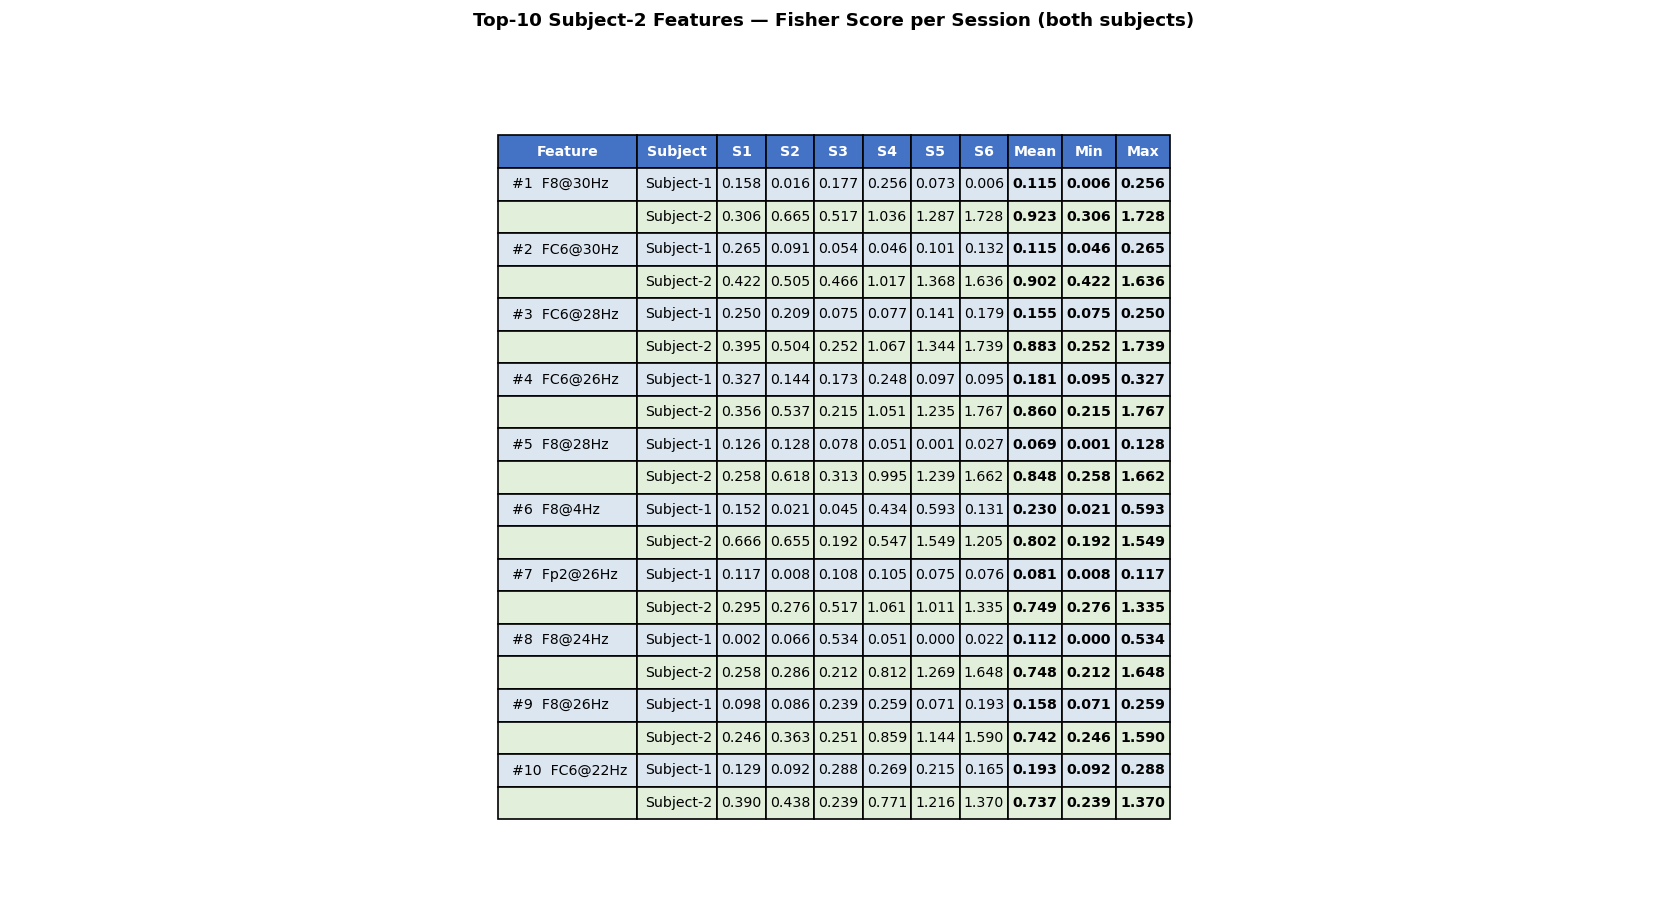

Saved fig_top10_fisher_scores.png


In [49]:
# ── Per-session Fisher scores for the top-10 Subject-2 features — PNG table ──

col_labels = ['Feature', 'Subject', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'Mean', 'Min', 'Max']

# Subject colour bands
COLORS = {
    'Subject-1': '#dce6f1',   # light blue
    'Subject-2': '#e2efda',   # light green
    'header':    '#4472c4',
    'feat_hdr':  '#d0d8e8',
}

cell_text  = []
cell_color = []

for rank, fi in enumerate(top10_idx, 1):
    ch_lbl  = CH_LABELS[fi // N_FREQ]
    freq_hz = FREQ_BINS[fi % N_FREQ]
    feat_label = f'#{rank}  {ch_lbl}@{freq_hz}Hz'

    for si, name in enumerate(subj_names):
        sc  = fisher_scores[si, :, fi]            # (6,)
        row = [feat_label if si == 0 else '',
               name,
               *[f'{v:.3f}' for v in sc],
               f'{np.nanmean(sc):.3f}',
               f'{np.nanmin(sc):.3f}',
               f'{np.nanmax(sc):.3f}']
        cell_text.append(row)

        bg = COLORS['Subject-1'] if si == 0 else COLORS['Subject-2']
        cell_color.append([bg] * len(col_labels))

n_rows = len(cell_text)
n_cols = len(col_labels)

fig, ax = plt.subplots(figsize=(14, n_rows * 0.35 + 0.8))
ax.axis('off')

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.35)

# Style header row
for col in range(n_cols):
    cell = tbl[0, col]
    cell.set_facecolor(COLORS['header'])
    cell.set_text_props(color='white', fontweight='bold')

# Style data rows
for row in range(1, n_rows + 1):
    for col in range(n_cols):
        tbl[row, col].set_facecolor(cell_color[row - 1][col])
        # Bold the summary columns
        if col >= 8:
            tbl[row, col].set_text_props(fontweight='bold')
        # Left-align feature label and subject name
        if col <= 1:
            tbl[row, col].set_text_props(ha='left')

# Wider columns for feature label and subject
tbl.auto_set_column_width(list(range(n_cols)))

ax.set_title('Top-10 Subject-2 Features — Fisher Score per Session (both subjects)',
             fontsize=11, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('fig_top10_fisher_scores.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved fig_top10_fisher_scores.png')

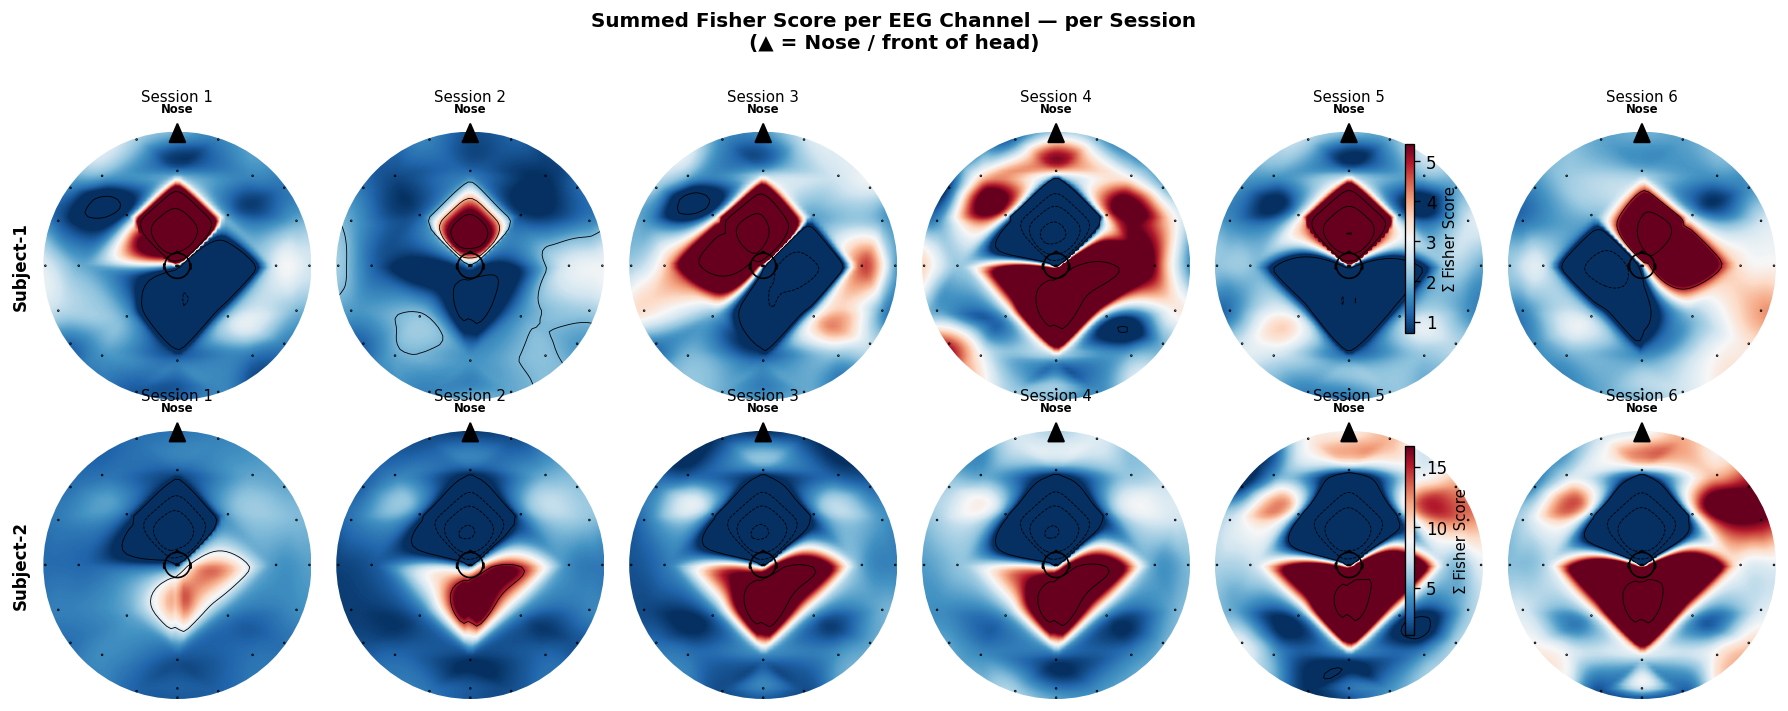

Saved fig_topoplot_fisher_per_session.png


In [51]:
# ── Topoplot: summed Fisher score per channel per session ─────────────────────
# Top of each topoplot = NOSE (front of head).
# pos2d was built as [-Y_eeg, X_eeg]; X_eeg points toward the nose in EEGLAB
# convention, so the +y axis of the plot = forward = nose.

channel_fs = fisher_scores.reshape(2, 6, N_CH, N_FREQ).sum(axis=-1)  # (2, 6, 32)

def add_nose_marker(ax):
    """Draw a filled triangle + 'Nose' label at the top-centre of a topomap axes."""
    from matplotlib.patches import FancyArrowPatch
    # Filled upward-pointing triangle in axis fraction coords
    tri_x = [0.47, 0.53, 0.50, 0.47]
    tri_y = [0.96, 0.96, 1.03, 0.96]
    ax.fill(tri_x, tri_y, transform=ax.transAxes,
            color='black', clip_on=False, zorder=5)
    ax.text(0.50, 1.06, 'Nose', transform=ax.transAxes,
            ha='center', va='bottom', fontsize=7,
            fontweight='bold', color='black', clip_on=False)

fig, axes = plt.subplots(2, 6, figsize=(15, 6))
fig.suptitle('Summed Fisher Score per EEG Channel — per Session\n'
             '(▲ = Nose / front of head)',
             fontsize=12, fontweight='bold', y=1.02)

for si, name in enumerate(subj_names):
    vmin = channel_fs[si].min()
    vmax = channel_fs[si].max()

    for se in range(6):
        ax = axes[si, se]
        data = channel_fs[si, se]

        im, _ = plot_topomap(
            data, pos2d,
            axes=ax,
            vlim=(vmin, vmax),
            cmap='RdBu_r',
            show=False,
            sensors=True,
            contours=4,
        )
        add_nose_marker(ax)
        ax.set_title(f'Session {se + 1}', fontsize=9, pad=18)
        if se == 0:
            ax.set_ylabel(name, fontsize=10, fontweight='bold', labelpad=8)

    cbar = fig.colorbar(im, ax=axes[si, :], shrink=0.75, pad=0.02)
    cbar.set_label('Σ Fisher Score', fontsize=9)

plt.tight_layout()
plt.savefig('fig_topoplot_fisher_per_session.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved fig_topoplot_fisher_per_session.png')

BEST FEATURE (highest Fisher score in Session 6) per subject
  Subject-1: feat #227  →  C4 @ 10 Hz
           FS per session: S1=0.518  S2=0.764  S3=0.540  S4=0.931  S5=0.603  S6=0.764

  Subject-2: feat #165  →  FC6 @ 26 Hz
           FS per session: S1=0.356  S2=0.537  S3=0.215  S4=1.051  S5=1.235  S6=1.767

SUBJECT-LEVEL TREND  (Mann-Kendall + Spearman, n=6 sessions)
  Subject-1
    Mann-Kendall : tau = +0.467   p = 0.2597  ns   trend: no trend
    Spearman ρ   : rho = +0.600   p = 0.2080  ns

  Subject-2
    Mann-Kendall : tau = +0.733   p = 0.0603  ns   trend: no trend
    Spearman ρ   : rho = +0.829   p = 0.0416  *

GROUP-LEVEL  Session-1 vs Session-6  (Wilcoxon signed-rank, n=2)
NOTE: n=2 → minimum achievable p = 0.500; interpret descriptively
  Session-1 values : Subject-1=0.518  Subject-2=0.356
  Session-6 values : Subject-1=0.764  Subject-2=1.767
  Δ (S6 − S1)      : Subject-1=+0.246  Subject-2=+1.411
  Wilcoxon (S6>S1) : W = 3.0   p = 0.2500  ns



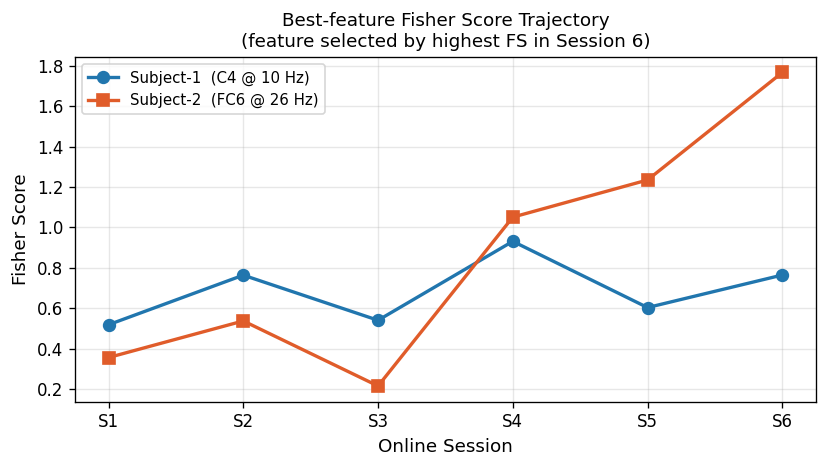

Saved fig_best_feature_trajectory.png


In [52]:
# ── Best feature per subject (highest FS in session 6) tracked across sessions
# Statistical analysis:
#   Subject level  — Mann-Kendall trend test (monotonic trend, n=6, non-parametric)
#                    + Spearman ρ as effect size
#   Group level    — Wilcoxon signed-rank session-1 vs session-6 (paired, non-parametric)
#                    NOTE: n=2 subjects → min achievable p = 0.5; interpret descriptively

from scipy.stats import spearmanr, wilcoxon, ttest_rel

sessions_arr = np.arange(1, 7)

best_feat_idx  = []   # per subject: feature index with max FS in session 6
best_feat_traj = []   # per subject: (6,) FS values across sessions

print('=' * 68)
print('BEST FEATURE (highest Fisher score in Session 6) per subject')
print('=' * 68)
for si, name in enumerate(subj_names):
    fi   = np.nanargmax(fisher_scores[si, 5, :])        # session 6 = index 5
    ch   = CH_LABELS[fi // N_FREQ]
    freq = FREQ_BINS[fi % N_FREQ]
    traj = fisher_scores[si, :, fi]                     # (6,)
    best_feat_idx.append(fi)
    best_feat_traj.append(traj)
    print(f'  {name}: feat #{fi}  →  {ch} @ {freq} Hz')
    print(f'           FS per session: ' +
          '  '.join([f'S{s+1}={v:.3f}' for s, v in enumerate(traj)]))
    print()

# ── Subject-level trend: Mann-Kendall + Spearman ─────────────────────────────
print('=' * 68)
print('SUBJECT-LEVEL TREND  (Mann-Kendall + Spearman, n=6 sessions)')
print('=' * 68)
for si, name in enumerate(subj_names):
    traj = best_feat_traj[si]
    mk_res  = mk.original_test(traj)
    rho, p_sp = spearmanr(sessions_arr, traj)
    print(f'  {name}')
    print(f'    Mann-Kendall : tau = {mk_res.Tau:+.3f}   p = {mk_res.p:.4f}'
          f'  {sig_stars(mk_res.p)}   trend: {mk_res.trend}')
    print(f'    Spearman ρ   : rho = {rho:+.3f}   p = {p_sp:.4f}'
          f'  {sig_stars(p_sp)}')
    print()

# ── Group-level: session 1 vs session 6, Wilcoxon signed-rank ────────────────
print('=' * 68)
print('GROUP-LEVEL  Session-1 vs Session-6  (Wilcoxon signed-rank, n=2)')
print('NOTE: n=2 → minimum achievable p = 0.500; interpret descriptively')
print('=' * 68)
s1_vals = np.array([best_feat_traj[si][0] for si in range(2)])
s6_vals = np.array([best_feat_traj[si][5] for si in range(2)])
try:
    stat, p_wx = wilcoxon(s6_vals, s1_vals, alternative='greater')
except ValueError:
    stat, p_wx = np.nan, 1.0

print(f'  Session-1 values : ' +
      '  '.join([f'{n}={v:.3f}' for n, v in zip(subj_names, s1_vals)]))
print(f'  Session-6 values : ' +
      '  '.join([f'{n}={v:.3f}' for n, v in zip(subj_names, s6_vals)]))
print(f'  Δ (S6 − S1)      : ' +
      '  '.join([f'{n}={d:+.3f}' for n, d in zip(subj_names, s6_vals - s1_vals)]))
print(f'  Wilcoxon (S6>S1) : W = {stat}   p = {p_wx:.4f}  {sig_stars(p_wx)}')
print()

# ── Plot: trajectories of the best feature per subject ────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
markers = ['o', 's']
colors  = ['#2176ae', '#e05c2a']

for si, name in enumerate(subj_names):
    fi   = best_feat_idx[si]
    ch   = CH_LABELS[fi // N_FREQ]
    freq = FREQ_BINS[fi % N_FREQ]
    traj = best_feat_traj[si]
    ax.plot(sessions_arr, traj, marker=markers[si], color=colors[si],
            linewidth=2, markersize=7,
            label=f'{name}  ({ch} @ {freq} Hz)')

ax.set_xlabel('Online Session', fontsize=11)
ax.set_ylabel('Fisher Score', fontsize=11)
ax.set_title('Best-feature Fisher Score Trajectory\n'
             '(feature selected by highest FS in Session 6)', fontsize=11)
ax.set_xticks(sessions_arr)
ax.set_xticklabels([f'S{s}' for s in sessions_arr])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_best_feature_trajectory.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved fig_best_feature_trajectory.png')

In [ ]:
# ── Subject-2: top-10 features in session 6, correlated with accuracy ─────────
#
# Statistical approach:
#   Spearman ρ  — primary test: non-parametric rank correlation, robust for n=6,
#                 appropriate when normality/linearity can't be assumed.
#   Pearson r   — reported alongside as reference.
#   Multiple comparisons (10 tests) corrected with Benjamini-Hochberg FDR.
#   Note: with n=6 the two-tailed Spearman significance threshold is |ρ|≈0.886
#   (p<0.05, uncorrected), so only very strong correlations can reach significance.

from scipy.stats import spearmanr, pearsonr

def bh_fdr(p_values, alpha=0.05):
    """Benjamini-Hochberg FDR correction. Returns (reject, p_adjusted)."""
    p = np.asarray(p_values, dtype=float)
    m = len(p)
    order = np.argsort(p)
    p_sorted = p[order]
    # Adjusted p-values (monotone-enforced from right to left)
    p_adj_sorted = np.minimum(1.0,
        np.minimum.accumulate((p_sorted * m / np.arange(1, m + 1))[::-1])[::-1])
    reject_sorted = p_adj_sorted <= alpha
    # Restore original order
    p_adj = np.empty(m)
    reject = np.empty(m, dtype=bool)
    p_adj[order] = p_adj_sorted
    reject[order] = reject_sorted
    return reject, p_adj

# ── Subject-2 accuracy per session (mean over 3 runs) ─────────────────────────
acc_s2 = accuracy[1].mean(axis=1)           # (6,)

# ── Top-10 features for Subject-2 in session 6 specifically ───────────────────
s2_s6_fs  = fisher_scores[1, 5, :]          # (448,) FS in session 6
top10_s6  = np.argsort(s2_s6_fs)[::-1][:10]

# ── Compute correlations ───────────────────────────────────────────────────────
results = []
for fi in top10_s6:
    fs_traj        = fisher_scores[1, :, fi]   # (6,) FS across sessions
    rho,  p_sp     = spearmanr(fs_traj, acc_s2)
    r,    p_pe     = pearsonr(fs_traj,  acc_s2)
    results.append(dict(fi=fi,
                        ch=CH_LABELS[fi // N_FREQ],
                        freq=FREQ_BINS[fi % N_FREQ],
                        fs_s6=s2_s6_fs[fi],
                        rho=rho, p_sp=p_sp,
                        r=r,     p_pe=p_pe))

# ── Benjamini-Hochberg FDR correction on Spearman p-values ────────────────────
p_raw = np.array([d['p_sp'] for d in results])
reject, p_fdr = bh_fdr(p_raw, alpha=0.05)
for i, d in enumerate(results):
    d['p_fdr']   = p_fdr[i]
    d['sig_fdr'] = reject[i]

# ── Sign test: are all ρ in the same direction? ────────────────────────────────
from scipy.stats import binomtest
n_pos = sum(d['rho'] > 0 for d in results)
n_neg = len(results) - n_pos
binom_res = binomtest(n_pos, len(results), p=0.5, alternative='two-sided')

# ── Print table ────────────────────────────────────────────────────────────────
print('Subject-2 — Top-10 Session-6 Features: Spearman ρ with accuracy')
print('n=6 sessions; two-tailed Spearman significance threshold ≈ |ρ|>0.886 (p<0.05)')
print()
print(f'  {"Rk":<3} {"Feature":<11} {"FS@S6":>6}  '
      f'{"ρ":>6}  {"p(raw)":>8}  {"sig":>4}  {"p(FDR)":>8}  {"FDR":>5}  {"r(Pearson)":>10}')
print('  ' + '-' * 72)
for rank, d in enumerate(results, 1):
    fdr_tag = 'FDR*' if d['sig_fdr'] else ''
    print(f'  {rank:<3} {d["ch"]:<4}@{d["freq"]:>2}Hz  {d["fs_s6"]:>6.3f}  '
          f'{d["rho"]:>+6.3f}  {d["p_sp"]:>8.4f}  {sig_stars(d["p_sp"]):>4}  '
          f'{d["p_fdr"]:>8.4f}  {fdr_tag:>5}  {d["r"]:>+10.3f}')

print()
n_sig_raw = sum(d['p_sp'] < 0.05 for d in results)
n_sig_fdr = sum(d['sig_fdr'] for d in results)
print(f'  Significant uncorrected (p<0.05) : {n_sig_raw} / 10 feature(s)')
print(f'  Significant FDR-corrected        : {n_sig_fdr} / 10 feature(s)')
print()
print(f'  Sign test (binomial): {n_pos} positive / {n_neg} negative ρ values')
print(f'  H0: ρ direction random (p=0.5 each) → p = {binom_res.pvalue:.4f}  {sig_stars(binom_res.pvalue)}')
print(f'  Interpretation: {"All features trend in the same direction (positive)" if n_pos == len(results) else f"{n_pos}/{len(results)} features trend positively"}')

# ── Plot: dual-axis FS trajectory vs accuracy for each feature ─────────────────
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for rank, (d, ax) in enumerate(zip(results, axes), 1):
    fs_traj = fisher_scores[1, :, d['fi']]
    ax2 = ax.twinx()

    l1, = ax.plot(sessions_arr, fs_traj,      'o-',  color='#2176ae', lw=2,   ms=5)
    l2, = ax2.plot(sessions_arr, acc_s2 * 100, 's--', color='#e05c2a', lw=1.5, ms=5)

    # Green border = uncorrected significant; gold = FDR significant; grey = ns
    if d['sig_fdr']:
        bcol, bw = '#d4a000', 3.0
    elif d['p_sp'] < 0.05:
        bcol, bw = '#228b22', 2.5
    else:
        bcol, bw = '#aaaaaa', 1.5
    for spine in ax.spines.values():
        spine.set_edgecolor(bcol); spine.set_linewidth(bw)

    sig_str = f"ρ={d['rho']:+.2f}  p={d['p_sp']:.3f}"
    if d['sig_fdr']:        sig_str += ' ★FDR'
    elif d['p_sp'] < 0.05:  sig_str += ' *'
    ax.set_title(f'#{rank} {d["ch"]}@{d["freq"]}Hz\n{sig_str}', fontsize=8)
    ax.set_xticks(sessions_arr)
    ax.set_xticklabels([f'S{s}' for s in sessions_arr], fontsize=7)
    ax.set_ylabel('Fisher Score', fontsize=7, color='#2176ae')
    ax2.set_ylabel('Acc %',       fontsize=7, color='#e05c2a')
    ax.tick_params(axis='y',  labelcolor='#2176ae', labelsize=7)
    ax2.tick_params(axis='y', labelcolor='#e05c2a', labelsize=7)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0],[0], color='#2176ae', marker='o',          label='Fisher Score (FS)'),
    Line2D([0],[0], color='#e05c2a', marker='s', ls='--', label='Accuracy (%)'),
    Line2D([0],[0], color='#228b22', lw=3,                label='p<0.05 uncorrected'),
    Line2D([0],[0], color='#d4a000', lw=3,                label='FDR significant'),
    Line2D([0],[0], color='#aaaaaa', lw=3,                label='ns'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle('Subject-2: Fisher Score vs Accuracy — Top-10 Session-6 Features\n'
             'Border colour = significance level',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_s2_fs_vs_accuracy.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved fig_s2_fs_vs_accuracy.png')